In [1]:
from matplotlib.colors import LogNorm
from collections import defaultdict, Counter
from cycler import cycler

import pandas as pd
import matplotlib.pyplot as plt
import fastplot
import ipaddress
import json
import seaborn as sns

%matplotlib inline

In [2]:
### SETUP

# Set to True if you have LaTeX locally installed and want to use it for plotting.
COMPILE_LATEX = True

if COMPILE_LATEX:
    plot_style = 'latex'
else:
    plot_style = 'sans-serif'


# Temporal evolution

In [3]:
df = pd.read_csv('data/vaps.csv')
df['date'] = pd.to_datetime(df['date'])
df.sort_values(by='date', inplace=True)

print(f'A total of {df["customer"].nunique()} ASes published an ASPA object between {min(df["date"]).date()} and {max(df["date"]).date()}.')

A total of 1646 ASes published an ASPA object between 2023-10-11 and 2026-03-31.


## ASPA Adoption

<Figure size 640x480 with 0 Axes>

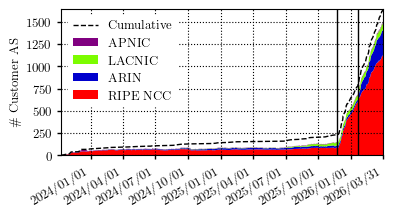

In [4]:
plot_data = (
    df
    .groupby(['date', 'rir'])['customer']
    .nunique()
    .unstack()
    .fillna(0)
    [['ripencc', 'arin', 'lacnic', 'apnic']]
    .rename(columns={
        'ripencc': 'RIPE NCC',
        'lacnic': 'LACNIC',
        'arin': 'ARIN',
        'apnic': 'APNIC'
    })
)

# Time series of the cumulative number of Customer ASes
customers_cumsum = (
    df
    .sort_values(by=['date', 'customer'])
    .drop_duplicates(subset=['customer'], keep='first')
    .groupby('date')['customer'].nunique()
    .cumsum()
)


CUSTOM_CYCLER=(cycler('color', ['r', 'mediumblue', 'lawngreen', 'purple', 'c']) +
              cycler('linestyle', ['-', '--', '-.', ':', (0, (3, 1, 1, 1)) ]))

fastplot.plot(plot_data, None, mode='timeseries_stacked',
              style=plot_style, legend=False, grid=True, fontsize=9,
              cycler=CUSTOM_CYCLER,
              ylabel=r'\# Customer AS', ytick_direction='out', # ylim=(0, 1400),
              yticks=([0, 250, 500, 750, 1000, 1250, 1500, 1750], None),
              xticks=(["2024-01-01", "2024-04-01", "2024-07-01", "2024-10-01", 
                "2025-01-01", "2025-04-01", "2025-07-01", "2025-10-01", 
                "2026-01-01", "2026-03-31"], None),
              xtick_direction='out', xticks_rotate=30)

# two vertical lines for the dates of 2025-11-21 and 2026-01-20
plt.axvline(pd.Timestamp('2025-11-21'), color='k', linestyle='-', linewidth=1)
plt.axvline(pd.Timestamp('2026-01-20'), color='k', linestyle='-', linewidth=1)


plt.gca().plot(customers_cumsum, color='k', linestyle='--', linewidth=1, label='Cumulative')

handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.gca().legend(
    handles[::-1], labels[::-1], loc='upper left', ncol=1, fontsize=9, numpoints=1,
    frameon=True, facecolor='white', edgecolor='white', framealpha=1, fancybox=False)

plt.savefig('figures/aspa_over_time.pdf', bbox_inches='tight')

## Persistence of ASPA Customers

<Figure size 640x480 with 0 Axes>

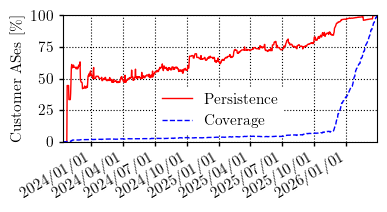

In [5]:
last_day = df['date'].max()
aspa_customers_last_day = set(df[df['date'] == last_day]['customer'])

# each day, % of ASPA Customers that are still in RPKI on last day
plot_data_1 = ( 
    df
    .groupby('date')
    ['customer']
    .agg(set)
    .apply(lambda day_customers: len(day_customers & aspa_customers_last_day) / len(day_customers) * 100)
)

# each day, % of Customer ASes of last that that were in the RPKI on that day
plot_data_2 = ( 
    df
    .groupby('date')
    ['customer']
    .agg(set)
    .apply(lambda day_customers: len(day_customers & aspa_customers_last_day) / len(aspa_customers_last_day) * 100)
)

fastplot.plot([('Persistence', plot_data_1), ('Coverage', plot_data_2)], None,
              mode='timeseries_multi', style=plot_style, grid=True, legend=True,
              ylabel=r'Customer ASes [\%]',
              xtick_direction='out', ytick_direction='out',
              xticks_rotate=30
)

plt.savefig('figures/persistence.pdf', bbox_inches='tight')

## ASPA-related RPKI events

In [6]:
first_appearance = df.groupby('customer')['date'].min()
df['prev_providers'] = df.groupby('customer')['providers'].shift(1)

customers_by_date = df.groupby('date')['customer'].apply(set).sort_index()
customers_by_month = df.groupby(pd.Grouper(key='date', freq='ME'))['customer'].agg(set).sort_index()
n_customers_per_day = customers_by_date.apply(len)
n_customers_per_month = customers_by_month.apply(len)

dates = customers_by_date.index

news = dict()
removals = dict()
comeback = dict()
updated = dict()

for i in range(1, len(dates)):
    prev_day = dates[i - 1]
    curr_day = dates[i]

    removals[curr_day] = set(customers_by_date[prev_day] - customers_by_date[curr_day])

    new_customers = customers_by_date[curr_day] - customers_by_date[prev_day]
    comeback[curr_day] = set(c for c in new_customers if first_appearance[c] < curr_day)
    news[curr_day] = set(c for c in new_customers if first_appearance[c] == curr_day)

    persistent_customers = customers_by_date[prev_day] & customers_by_date[curr_day]
    day_df = df[(df['date'] == curr_day) & (df['customer'].isin(persistent_customers))]
    day_df = df[(df['date'] == curr_day)]
    updated[curr_day] = set(
            day_df[day_df['prev_providers'].notna() & (day_df['providers'] != day_df['prev_providers'])]['customer']
        )


# for each day D, the number of customers that were present on D - 1 but are not in df on D
s_removals = pd.Series(removals, name='removals')
s_removals.index.name = 'date'

# for each day D, the number of customers that were absent on D - 1 but are in df on D, AND D is after the first appearance of those customer
s_comeback = pd.Series(comeback, name='comeback')
s_comeback.index.name = 'date'

# for each day D, the number of customers that (1) were also present on D - 1, (2) prev_providers != providers
s_updated = pd.Series(updated, name='updated')
s_updated.index.name = 'date'

# for each day D, the number of customers that were absent on D - k for any k > 0
s_news = pd.Series(news, name='news')
s_news.index.name = 'date'

monthly_removals = s_removals.resample('ME').apply(lambda x: set.union(*x)).apply(len)
monthly_comeback = s_comeback.resample('ME').apply(lambda x: set.union(*x)).apply(len)
monthly_updated = s_updated.resample('ME').apply(lambda x: set.union(*x)).apply(len)
monthly_news = s_news.resample('ME').apply(lambda x: set.union(*x)).apply(len)

monthly_removals_rel = monthly_removals / n_customers_per_month
monthly_comeback_rel = monthly_comeback / n_customers_per_month
monthly_updated_rel = monthly_updated / n_customers_per_month
monthly_news_rel = monthly_news / n_customers_per_month

<Figure size 640x480 with 0 Axes>

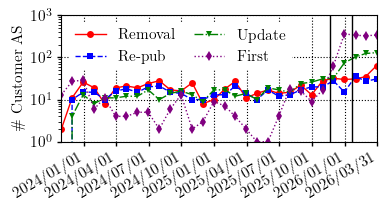

In [7]:
fastplot.plot(
    [('Removal', monthly_removals), ('Re-pub', monthly_comeback), ('Update', monthly_updated), ('First', monthly_news)], None, 
    mode='timeseries_multi', style=plot_style, grid=True, 
    legend_fontsize=11,
    legend=True, legend_ncol=2, 
    legend_args={'columnspacing': 1.25},
    yscale='log', 
    ylabel=r'\# Customer AS', ytick_direction='out', xtick_direction='out',
    xticks=(["2024-01-01", "2024-04-01", "2024-07-01", "2024-10-01", 
             "2025-01-01", "2025-04-01", "2025-07-01", "2025-10-01", 
             "2026-01-01", "2026-03-31"], None),
    xticks_rotate=30, cycler=fastplot.CYCLER_LINESPOINTS, plot_args={'markersize': 5})


# two vertical lines for the dates of 2025-11-21 and 2026-01-20
plt.axvline(pd.Timestamp('2025-11-21'), color='k', linestyle='-', linewidth=1)
plt.axvline(pd.Timestamp('2026-01-20'), color='k', linestyle='-', linewidth=1)

plt.savefig('figures/aspa_dynamics_absolute.pdf', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

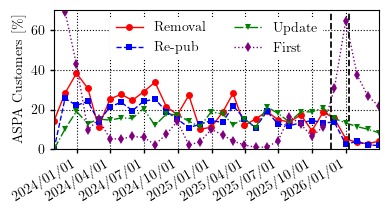

In [8]:
fastplot.plot(
    [('Removal', monthly_removals_rel * 100), ('Re-pub', monthly_comeback_rel * 100), 
    ('Update', monthly_updated_rel * 100), ('First', monthly_news_rel * 100)
    ],
    None, mode='timeseries_multi', style=plot_style, grid=True, 
    legend=True, 
    ylim=(0, 70),
    ylabel=r'ASPA Customers [\%]', ytick_direction='out', xtick_direction='out',
    legend_ncol=2, fontsize=10,
    xticks_rotate=30, cycler=fastplot.CYCLER_LINESPOINTS, plot_args={'markersize': 5})

# two vertical lines for the dates of 2025-11-21 and 2026-01-10
plt.axvline(pd.Timestamp('2025-11-21'), color='k', linestyle='--', linewidth=1.25)
plt.axvline(pd.Timestamp('2026-01-10'), color='k', linestyle='--', linewidth=1.25)

plt.savefig('figures/aspa_dynamics_relative.pdf', bbox_inches='tight')

## Changes in listed providers

<Figure size 640x480 with 0 Axes>

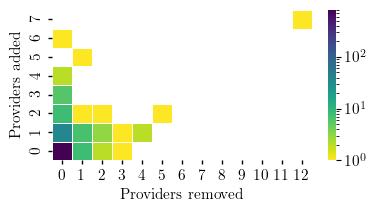

In [9]:
customers_prior_feb2026 = set(df.query('date < "2026-02-01"')['customer'])

df['providers_set'] = df['providers'].apply(lambda s: set(s.split(' ')) if pd.notna(s) else set())
df['prev_providers'] = df.sort_values(by='date').groupby('customer')['providers_set'].shift(1, fill_value=set())

t = (
    df
    .query('customer in @customers_prior_feb2026')
    .query('date > "2026-03-01" and date < "2026-04-01"') 
        # > because we don't want changes occurred between Feb 28th and March 1st
    .assign(
        added_provs=lambda row: row['providers_set'] - row['prev_providers'],
        removed_provs=lambda row: row['prev_providers'] - row['providers_set']
    )
    .assign(
        n_added_provs=lambda row: row['added_provs'].apply(len),
        n_removed_provs=lambda row: row['removed_provs'].apply(len)
    )
    .groupby('customer')
    [['n_added_provs', 'n_removed_provs']]
    .sum()
    .reset_index()
)

plot_data = t.pivot_table(
    columns='n_removed_provs',
    index='n_added_provs',
    values='customer',
    aggfunc='count',
    fill_value=0
)

max_n_removed = t['n_removed_provs'].max()
max_n_added = t['n_added_provs'].max()

full_cols = range(0, max_n_removed + 1)
full_rows = range(0, max_n_added + 1)

plot_data = plot_data.reindex(index=full_rows, columns=full_cols, fill_value=0)

def callback(plt):
    ax = plt.gca()
    sns.heatmap(plot_data, annot=False, fmt='g', ax=ax, cmap='viridis_r', norm=LogNorm(), linewidths=.5, linecolor='white')
    ax.invert_yaxis()


fastplot.plot(None, None, mode='callback', callback=callback, style=plot_style, 
            xlabel='Providers removed', ylabel='Providers added',
            xtick_direction='out', ytick_direction='out',
    )

plt.savefig('figures/providers_changes.pdf', bbox_inches='tight')

# Customer ASes characterization
- Only considering ASes from the last day of available data

In [10]:
df = pd.read_csv('data/vaps.csv')
df['date'] = pd.to_datetime(df['date'])

last_date = df['date'].max()
first_appearance = df.groupby('customer')['date'].min()

df = df[df['date'] == last_date]
df['first'] = df['customer'].map(first_appearance)

aspa = (
    df
        .set_index('customer')
        ['providers']
        .apply(lambda prov: set(prov.split(' ')))
        .to_dict()
)

print(f'{df["customer"].nunique()} ASPA Customers as of {last_date}')
print(f'Of which only {df[df['first'] < '2025-11-26']['customer'].nunique()} first published a valid ASPA before Nov. 22, 2025')

1505 ASPA Customers as of 2026-03-31 00:00:00
Of which only 142 first published a valid ASPA before Nov. 22, 2025


## Who are they?

In [11]:
TIER_1_ASES = [
    # The list of Tier 1 ASes is obtained from https://bgp.tools/kb/what-is-a-upstream
    "AS174",   # Cogent
    "AS701",   # Verizon
    "AS1299",  # Arelion
    "AS2914",  # NTT
    "AS3257",  # GTT
    "AS3320",  # DTAG
    "AS3356",  # Lumen
    "AS3491",  # PCCW
    "AS5511",  # Orange
    "AS6453",  # TATA
    "AS6461",  # Zayo
    "AS6762",  # Sparkle
    "AS6830",  # Liberty Global
    "AS6939",  # HE (IPv6)
    "AS7018",  # AT&T
    "AS12956"  # Telefonica
]


print('Tier-1 Customer ASes:')
for asn in TIER_1_ASES:
    if asn in df['customer'].unique():
        print('\t', asn)

print('\n', '- - ' * 15, '\n')

print('Number of ASPA Customers per Regional Internet Registry (RIR):\n')
print(df.groupby('rir')['customer'].count().to_string())

Tier-1 Customer ASes:
	 AS174
	 AS1299
	 AS6830
	 AS7018

 - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  

Number of ASPA Customers per Regional Internet Registry (RIR):

rir
apnic        10
arin        288
lacnic       72
ripencc    1135


In [12]:
tags = dict()

with open('data/bgptools/data.json') as f:
    tags = json.load(f)

aspa_customer_tags = defaultdict(set)

for tag, asns in tags.items():
    # for asn in asns:
    #     if f'AS{asn}' in set(df['customer'].unique()):
    #         aspa_customer_tags[f'AS{asn}'].add(tag)
    for aspa_customer in df['customer'].unique():
        if aspa_customer in {f'AS{asn}' for asn in asns}:
            aspa_customer_tags[aspa_customer].add(tag)

In [13]:
# https://bgp.tools/tags/

for tag, asns in tags.items():
    asns_in_aspa = set(aspa.keys()) & set(f'AS{asn}' for asn in asns)
    if asns_in_aspa:
        print(f'{tag}: {len(asns_in_aspa)} Customer ASes')


uni.: 19 Customer ASes
mobi: 8 Customer ASes
a10k: 35 Customer ASes
cdn.: 5 Customer ASes
tor.: 94 Customer ASes
vpsh: 148 Customer ASes
rpki: 176 Customer ASes
feed: 240 Customer ASes
icri: 12 Customer ASes
anyc: 68 Customer ASes
even: 5 Customer ASes
dsl.: 60 Customer ASes
ddos: 12 Customer ASes
vpn.: 24 Customer ASes
gov.: 18 Customer ASes
pers: 250 Customer ASes
bizn: 35 Customer ASes
jv6.: 213 Customer ASes
corp: 28 Customer ASes


## Number of listed providers

<Figure size 640x480 with 0 Axes>

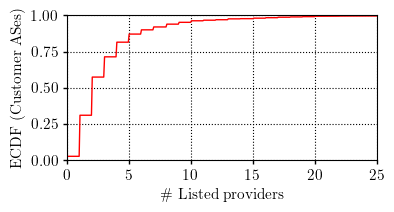

In [14]:
plot_data = [len(v - {'AS0',}) for v in aspa.values()]

fastplot.plot(plot_data, None,
              mode='CDF', style=plot_style, grid=True,
              xtick_direction='out', ytick_direction='out',
              xlabel=r'\# Listed providers', ylabel='ECDF (Customer ASes)',
              xlim=(0, 25))

plt.savefig('figures/cdf_aspa_providers.pdf')

## ASes size
- Customer cone size obtained using CAIDA data (inferred AS Relationships of March 2026)
- IP to ASN mappings obtained from RIPE RISwhois dump of March 31, 2026.
  - https://ris.ripe.net/docs/ris-whois/#riswhois-dumps

In [15]:
ascone = Counter()

with open('data/caida/2026-03-cones.txt', 'r') as f:
    for line in f:
        if line.startswith('#'):
            continue
        asn, cone = line.strip().split(' ', 1)
        if f'AS{asn}' not in aspa:
            continue
        ascone[f'AS{asn}'] = len(cone.strip().split(' '))

for asn in aspa:
    if asn not in ascone:
        ascone[asn] = 1

In [16]:
ipv4_subnets = defaultdict(list)

with open('data/riswhoisdump.IPv4') as f:
    for line in f:
        line = line.strip()
        if line.startswith('%') or len(line) == 0:
            continue
        
        asn, prefix, _ = line.split('\t')
        if f'AS{asn}' not in aspa:
            continue
        
        subnet, size = prefix.split('/')
        if size == '0':
            continue

        ipv4_subnets[asn].append(ipaddress.IPv4Network(prefix))

ipv4_addresses = {asn: sum((net.num_addresses for net in nets)) for asn, nets in ipv4_subnets.items()}
ipv4_24_subnets = {customer: ipv4_addresses.get(customer[2:], 0) / 256 for customer in aspa}

In [17]:
ipv6_subnets = defaultdict(list)

with open('data/riswhoisdump.IPv6') as f:
    for line in f:
        line = line.strip()
        if line.startswith('%') or len(line) == 0:
            continue
        
        asn, prefix, _ = line.split('\t')
        if f'AS{asn}' not in aspa:
            continue       

        subnet, size = prefix.split('/')
        if size == '0':
            continue

        ipv6_subnets[asn].append(ipaddress.IPv6Network(prefix))

ipv6_addresses = {asn: sum((net.num_addresses for net in nets)) for asn, nets in ipv6_subnets.items()}
ipv6_48_subnets = {customer: ipv6_addresses.get(customer[2:], 0) / 2**80 for customer in aspa}

<Figure size 640x480 with 0 Axes>

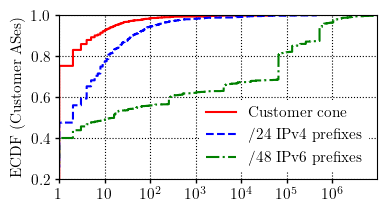

In [18]:
def callback(plt):
    ax = plt.gca()
    ax.ecdf(ascone.values(), label='Customer cone')
    ax.ecdf(ipv4_24_subnets.values(), label='/24 IPv4 prefixes')
    ax.ecdf(ipv6_48_subnets.values(), label='/48 IPv6 prefixes')

fastplot.plot(None, None,
              mode='callback', callback=callback,
              style=plot_style, grid=True, 
              ylim=(0.2, 1), xlim=(1, 10**7 - 4*10**5),
              legend=True, 
              xticks=([1, 10, 10**2, 10**3, 10**4, 10**5, 10**6], 
                        [1, 10, r"$10^2$", r"$10^3$", r"$10^4$", r"$10^5$", r"$10^6$"]),
              xscale='log', xtick_direction='out', ytick_direction='out',
              ylabel='ECDF (Customer ASes)')

plt.savefig('figures/aspa_customer_size.pdf')